In [3]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Multi-source, multi-size loader for */eval_rollout.jsonl.
# ALL sources are the max_n=13 sweep (eval = 200 queries, numbers up to 13).
# The old logs/family_sweep is max_n=6 (eval = 52, numbers <= 6) and is EXCLUDED
# — mixing it in (0.6B/1.7B at max_n=6 vs 4B at max_n=13) was the earlier bug.
#   0.6B + 1.7B sweep  -> logs/June15_0617_sweep_g24          (<m>_<size>_s<seed>/Qwen__*/run/...)
#   1.7B lottery       -> logs/June15_0617_lottery_absorb_g24 (buf16_a1/a2_s*/Qwen__*/run/...)
#   4B sweep           -> logs/June15_4_sweep_g24/sweep_base
#   4B lottery         -> logs/June15_4_sweep_g24/lottery_4b  (buf16_a1, buf4_a1; grow_* empty)
# A source whose dir name contains "lottery" gets its methods prefixed with
# "lottery_" so lottery runs align across dirs (buf16_a1 -> lottery_buf16_a1).
# Checkpoint canonicalisation: step==0 -> "init", any nonzero -> "final".
# avg/union unit = physical run (numeric seeds repeat across base/grpo & dirs).
# ---------------------------------------------------------------------------
SOURCES = [
    "logs/June15_0617_sweep_g24",            # 0.6B + 1.7B sweep methods
    "logs/June15_17_lottery_absorb_g24",   # 1.7B lottery (buf16_a1/a2)
    "logs/June15_06_lottery_absorb_g24",   # 0.6B lottery (buf16_a1/a2)
    "logs/June15_4_sweep_g24/sweep_base",    # 4B sweep methods
    "logs/June15_4_sweep_g24/lottery_4b",    # 4B lottery (buf16_a1, buf4_a1)
]
SIZE_ORDER   = ["0.6B", "1.7B", "4B"]
METHOD_MERGE = {"grpo": "base"}   # base and grpo are the same config -> pool seeds

def parse_run(run_name: str, full_path: str, is_lottery_src: bool):
    m = re.search(r"(\d+\.?\d*B)", run_name)
    if m:
        size = m.group(1)
    else:
        pm = re.search(r"Qwen3-(\d+\.?\d*B)", full_path)
        size = pm.group(1) if pm else "unknown"
    toks = run_name.split("_")
    method = "_".join(t for t in toks
                      if not re.fullmatch(r"\d+\.?\d*B", t) and not re.fullmatch(r"s\d+", t))
    if is_lottery_src and not method.startswith("lottery"):
        method = "lottery_" + method
    method = METHOD_MERGE.get(method, method)
    return method, size

def load_sources(sources) -> pd.DataFrame:
    rows = []
    for src in sources:
        root = Path(src)
        if not root.exists():
            raise FileNotFoundError(f"source dir missing: {src}")
        is_lottery_src = "lottery" in root.name.lower()
        for f in sorted(root.glob("**/eval_rollout.jsonl")):
            run_name = f.relative_to(root).parts[0]
            method, size = parse_run(run_name, str(f), is_lottery_src)
            n = 0
            for line in f.open():
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                rows.append({
                    "method":   method,
                    "size":     size,
                    "run":      f"{root.name}/{run_name}",   # unique physical-run id
                    "step":     int(r["global_step"]),
                    "query":    tuple(r["numbers"]),
                    "decoding": r["decoding"],
                    "correct":  bool(r["correct"]),
                })
                n += 1
            if n == 0:
                print(f"[skip empty] {src}/{run_name}")
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No eval rollouts loaded")
    df = df[df["size"].isin(SIZE_ORDER)].copy()
    df["size"]  = pd.Categorical(df["size"], SIZE_ORDER, ordered=True)
    df["stage"] = pd.Categorical(np.where(df["step"] == 0, "init", "final"),
                                 ["init", "final"], ordered=True)
    return df

df = load_sources(SOURCES)

# --- HARD GUARD: every loaded run must be max_n=13 (numbers up to 13, eval~200).
# A stale max_n=6 set (numbers<=6, eval~52) would silently corrupt comparisons.
_maxnum = max(max(q) for q in df["query"])
assert _maxnum >= 7, f"max number in eval = {_maxnum} -> max_n=6 data leaked in! ABORT."
_nq = df[df.stage == "final"].groupby("run", observed=True)["query"].nunique()
bad = _nq[_nq < 195]
assert bad.empty, f"runs with <195 final-eval queries (not max_n=13):\n{bad}"
print(f"GUARD OK: max number={_maxnum} (max_n=13); "
      f"final eval queries/run in [{_nq.min()}..{_nq.max()}] across {len(_nq)} runs")

print(f"Loaded {len(df)} rollouts")
print("sizes:  ", [s for s in SIZE_ORDER if s in df['size'].unique()])
print("methods:", sorted(df.method.unique()))
print("\nphysical runs per (method, size)  [base includes grpo, lottery_* included]:")
print(df.groupby(["method", "size"], observed=True).run.nunique().unstack().fillna(0).astype(int))


[skip empty] logs/June15_17_lottery_absorb_g24/grow_s0
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s1
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s10
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s11
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s12
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s13
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s14
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s15
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s2
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s3
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s4
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s5
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s6
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s7
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s8
[skip empty] logs/June15_17_lottery_absorb_g24/grow_s9
[skip empty] logs/June15_06_lottery_absorb_g24/grow_s0
[skip empty] logs/June15_06_lottery_absorb_g24/grow_s1
[ski

In [4]:
# ---------------------------------------------------------------------------
# Metrics grouped by (method, size, stage). Unit = physical run.
#   per-run:  greedy@1 (1 greedy decode/query), pass@1 (mean over sampled rows),
#             pass@K  (per query any sample correct, K=#samples)
#   avg_*  =  mean over ALL runs (+ std)              -> single-model expectation
#   union_* = per query solved if ANY run solves it    -> lottery/ensemble ceiling
# stage: "init" = step 0 baseline, "final" = trained checkpoint.
#
# UNION SEED CAP: union accuracy grows with #seeds, so to keep it comparable
# across methods we cap base (= base+grpo = 8 runs) to the first 4 sorted runs
# for the union metric only. avg/std still use all runs.
# ---------------------------------------------------------------------------
GKEY = ["method", "size", "stage"]
greedy = df[df.decoding == "greedy"]
sample = df[df.decoding == "sample"]
K = int(sample.groupby(["run", "stage", "query"], observed=True).size().max())
print(f"samples per query (K) = {K}")

# --- per-run scores ---
g1 = greedy.groupby(GKEY + ["run"], observed=True).correct.mean().rename("greedy@1")
p1 = sample.groupby(GKEY + ["run"], observed=True).correct.mean().rename("pass@1")
pK = (sample.groupby(GKEY + ["run", "query"], observed=True).correct.any()
            .groupby(GKEY + ["run"], observed=True).mean().rename(f"pass@{K}"))
per_run = pd.concat([g1, p1, pK], axis=1).reset_index()

# --- avg ± std across ALL runs ---
avg = per_run.groupby(GKEY, observed=True)[["greedy@1", "pass@1", f"pass@{K}"]].agg(["mean", "std"])
avg.columns = [f"avg_{m}_{s}" for m, s in avg.columns]
avg = avg.reset_index()

# --- union across runs (per-query OR), capping seeds per method ---
UNION_SEED_CAP = {"base": 4}   # base = base+grpo (8 runs) -> use first 4 for union
_run_order = (df[["method", "size", "stage", "run"]].drop_duplicates()
                .sort_values(["method", "size", "stage", "run"]))
def _cap_runs(g):
    cap = UNION_SEED_CAP.get(g.name[0])
    return g.head(cap) if cap else g
_allowed = (_run_order.groupby(["method", "size", "stage"], observed=True, group_keys=False)
                      .apply(_cap_runs))
_allowed["_keep"] = True
greedy_u = greedy.merge(_allowed, on=["method", "size", "stage", "run"], how="inner")
sample_u = sample.merge(_allowed, on=["method", "size", "stage", "run"], how="inner")

u_g1 = (greedy_u.groupby(GKEY + ["query"], observed=True).correct.any()
               .groupby(GKEY, observed=True).mean().rename("union_greedy@1"))
u_pK = (sample_u.groupby(GKEY + ["query"], observed=True).correct.any()
               .groupby(GKEY, observed=True).mean().rename(f"union_pass@{K}"))
union_n = greedy_u.groupby(GKEY, observed=True).run.nunique().rename("union_n_runs")
union = pd.concat([u_g1, u_pK, union_n], axis=1).reset_index()

n_runs = per_run.groupby(GKEY, observed=True).run.nunique().rename("n_runs").reset_index()
summary = (avg.merge(union, on=GKEY).merge(n_runs, on=GKEY)
              .sort_values(["size", "stage", "method"]))
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary


samples per query (K) = 8


/var/folders/bt/rngwf7wj73x2zfr_7chtd0jh0000gn/T/ipykernel_99850/2630423662.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_cap_runs))


,method,size,stage,avg_greedy@1_mean,avg_greedy@1_std,avg_pass@1_mean,avg_pass@1_std,avg_pass@8_mean,avg_pass@8_std,union_greedy@1,union_pass@8,union_n_runs,n_runs
0,base,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.028,0.125,0.670,4,8
6,buf_base,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
12,inj_inc,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
17,inj_roll,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
22,insert_max,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
27,insert_max_min,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
32,insert_min,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4
37,lottery_buf16_a1,0.6B,init,0.138,0.019,0.114,0.011,0.500,0.049,0.270,0.775,4,4
42,lottery_buf16_a2,0.6B,init,0.145,0.018,0.149,0.023,0.568,0.047,0.320,0.830,4,4
47,resamp,0.6B,init,0.077,0.006,0.069,0.007,0.370,0.030,0.125,0.670,4,4


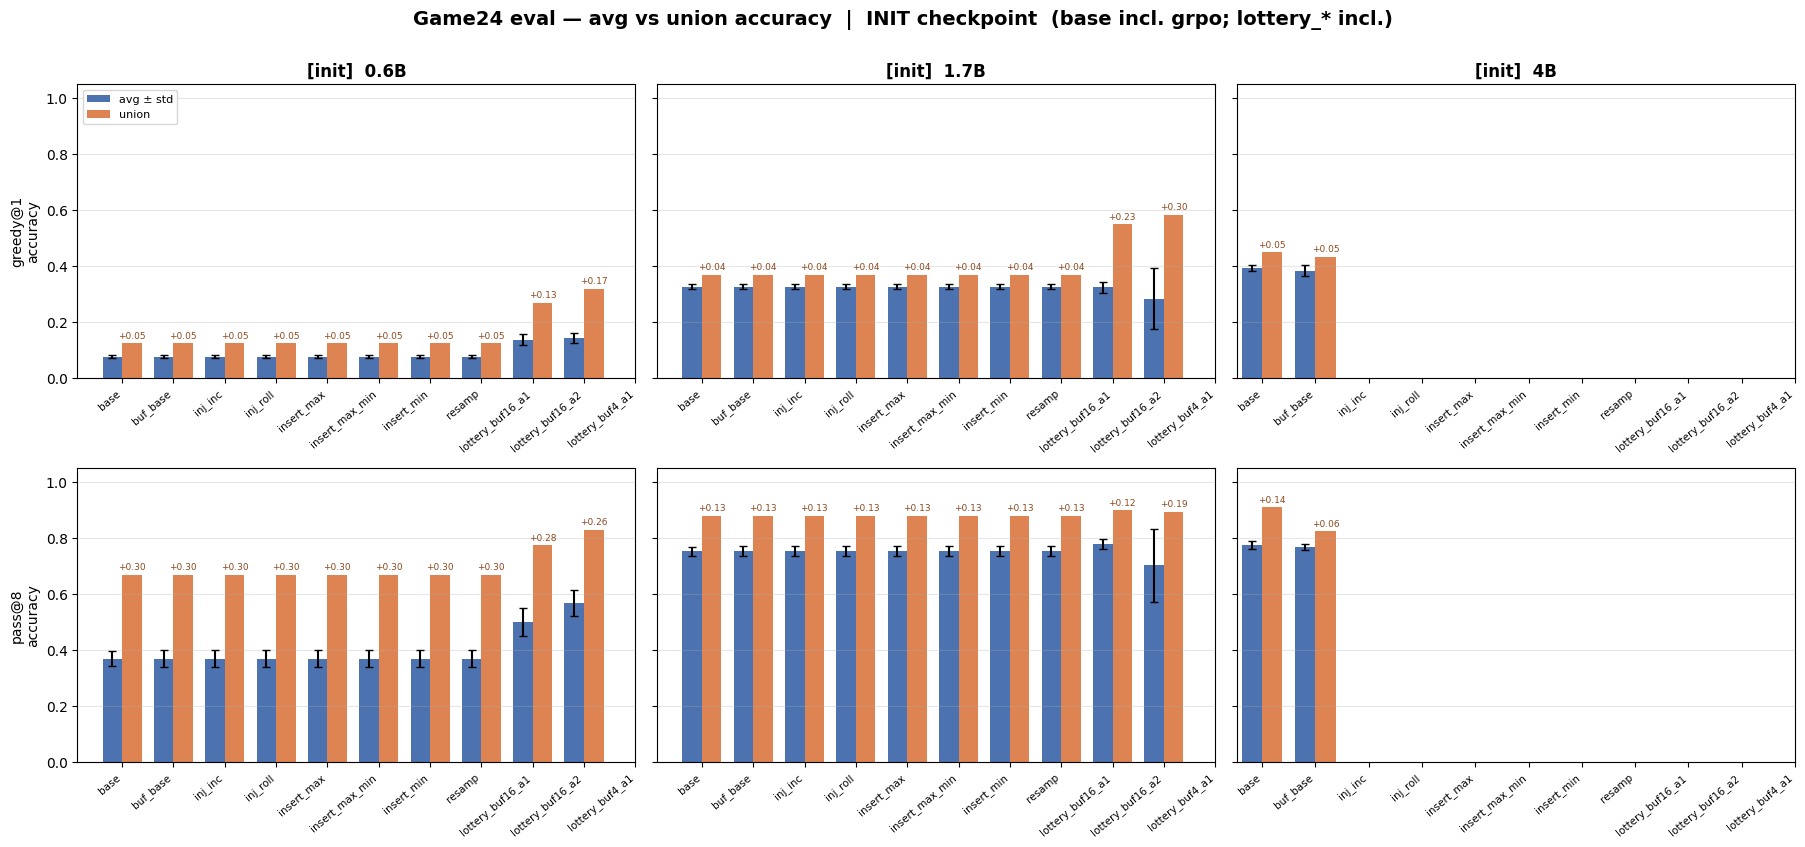

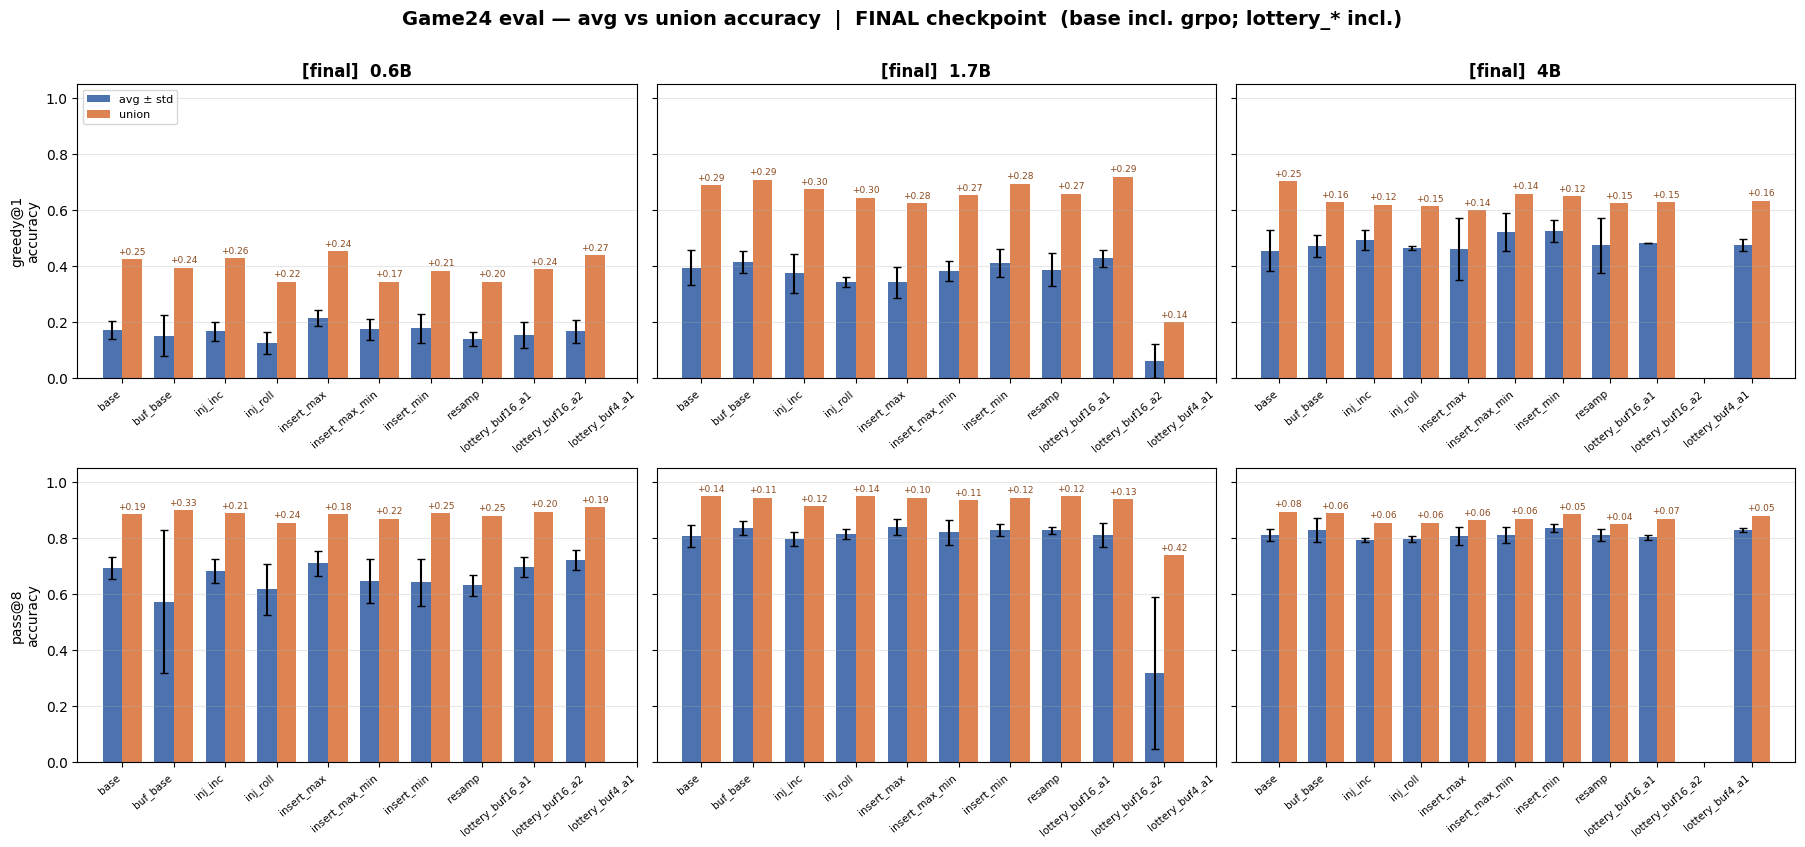

In [5]:
# ---------------------------------------------------------------------------
# Histogram: avg (mean over runs, ±std) vs union (any-run-solves), per stage.
# Layout per stage: rows = metric (greedy@1, pass@K), cols = size (0.6B,1.7B,4B).
# x = method (lottery_* included); annotated avg->union gap = ensemble headroom.
# NOTE: this loop renders TWO figures: stage="init" (step 0, all methods are the
# same untrained base -> identical bars) THEN stage="final" (trained checkpoint).
# Compare against summary[summary.stage=="final"] for the trained numbers.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

sizes = [s for s in SIZE_ORDER if s in summary["size"].unique()]
metric_specs = [("greedy@1", "union_greedy@1", "avg_greedy@1_mean", "avg_greedy@1_std"),
                (f"pass@{K}", f"union_pass@{K}", f"avg_pass@{K}_mean", f"avg_pass@{K}_std")]
# order: sweep methods first, lottery_* last
sweep_m   = sorted(m for m in summary.method.unique() if not m.startswith("lottery"))
lottery_m = sorted(m for m in summary.method.unique() if m.startswith("lottery"))
all_methods = sweep_m + lottery_m

for stage in ["init", "final"]:
    if stage not in summary["stage"].unique():
        continue
    fig, axes = plt.subplots(len(metric_specs), len(sizes),
                             figsize=(max(5, 0.55 * len(all_methods)) * len(sizes),
                                      4.2 * len(metric_specs)),
                             squeeze=False, sharey="row")
    for ri, (label, ucol, mcol, scol) in enumerate(metric_specs):
        for ci, size in enumerate(sizes):
            ax = axes[ri][ci]
            sub = (summary[(summary.stage == stage) & (summary["size"] == size)]
                   .set_index("method").reindex(all_methods))
            x = np.arange(len(all_methods)); w = 0.38
            means  = sub[mcol].values
            stds   = np.nan_to_num(sub[scol].values)
            unions = sub[ucol].values
            ax.bar(x - w/2, means, w, yerr=stds, capsize=3, color="#4C72B0", label="avg ± std")
            ax.bar(x + w/2, unions, w, color="#DD8452", label="union")
            for xi, (mn, u) in enumerate(zip(means, unions)):
                if np.isfinite(mn) and np.isfinite(u):
                    ax.text(xi + w/2, u + 0.01, f"+{u-mn:.2f}", ha="center",
                            va="bottom", fontsize=6.5, color="#8C4A1F")
            ax.set_xticks(x); ax.set_xticklabels(all_methods, rotation=40, ha="right", fontsize=7.5)
            ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
            if ri == 0:
                ax.set_title(f"[{stage}]  {size}", fontsize=12, fontweight="bold")
            if ci == 0:
                ax.set_ylabel(f"{label}\naccuracy")
            if ri == 0 and ci == 0:
                ax.legend(fontsize=8, loc="upper left")
    fig.suptitle(f"Game24 eval — avg vs union accuracy  |  {stage.upper()} checkpoint  "
                 f"(base incl. grpo; lottery_* incl.)", y=1.003, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()


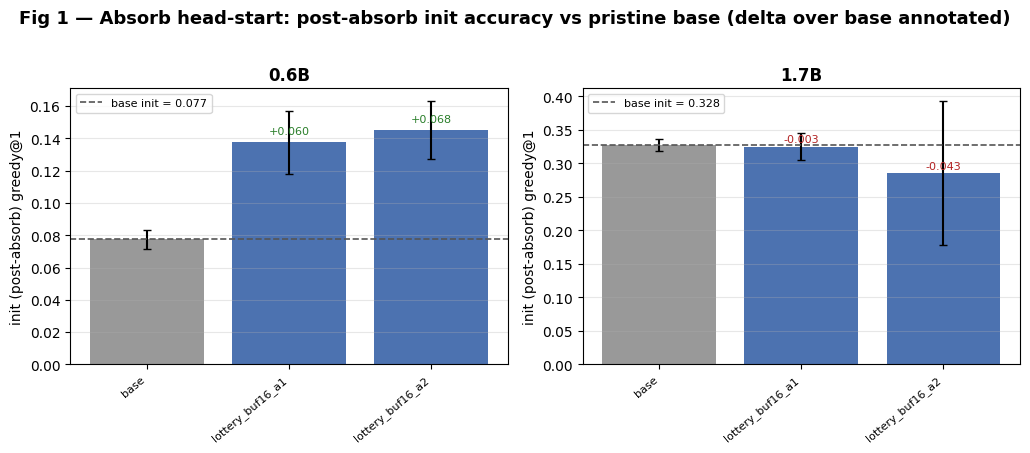

In [6]:
# ===========================================================================
# FIGURE 1 — Absorb impact on INITIAL performance.
# The lottery "init" eval is logged AFTER absorb_buffer() runs its pre-train
# gradient updates (eval_on_start fires inside train(), post-absorb), so its
# step-0 model is base+absorb. Plain methods' init = pristine base. This shows
# the absorbed model already beats base before any on-policy training.
# Only sizes/configs that actually logged an init eval appear (4B lottery has none).
# ===========================================================================
import matplotlib.pyplot as plt

init = summary[summary.stage == "init"]
# keep only sizes that have at least one lottery init row (else nothing to show)
sizes_f1 = [s for s in SIZE_ORDER
            if s in init["size"].unique()
            and init[(init["size"] == s) & init.method.str.startswith("lottery")].shape[0] > 0]

fig, axes = plt.subplots(1, len(sizes_f1), figsize=(5.2 * len(sizes_f1), 4.4), squeeze=False)
for ci, size in enumerate(sizes_f1):
    ax = axes[0][ci]
    sub = init[init["size"] == size].set_index("method")
    base_acc = sub.loc["base", "avg_greedy@1_mean"] if "base" in sub.index else np.nan
    lot = sorted(m for m in sub.index if m.startswith("lottery"))
    methods = (["base"] if "base" in sub.index else []) + lot
    vals = [sub.loc[m, "avg_greedy@1_mean"] for m in methods]
    errs = [np.nan_to_num(sub.loc[m, "avg_greedy@1_std"]) for m in methods]
    colors = ["#999999" if m == "base" else "#4C72B0" for m in methods]
    x = np.arange(len(methods))
    ax.bar(x, vals, yerr=errs, capsize=3, color=colors)
    if np.isfinite(base_acc):
        ax.axhline(base_acc, ls="--", lw=1.2, color="#555555",
                   label=f"base init = {base_acc:.3f}")
    for xi, (m, v) in enumerate(zip(methods, vals)):
        if m != "base" and np.isfinite(v) and np.isfinite(base_acc):
            ax.text(xi, v + 0.004, f"{v - base_acc:+.3f}", ha="center", va="bottom",
                    fontsize=8, color=("#2A7E2A" if v >= base_acc else "#B22222"))
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=40, ha="right", fontsize=8)
    ax.set_title(size, fontsize=12, fontweight="bold")
    ax.set_ylabel("init (post-absorb) greedy@1")
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Fig 1 — Absorb head-start: post-absorb init accuracy vs pristine base "
             "(delta over base annotated)", y=1.02, fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# This is important: it validates the "failure mode" of absorbing steps actually degrades performance
#                    showing the inefficiency of off-policy training without extra tricks
# Second Storyline:  naive "healthy group replay from different seeds" degrade performance, off-policy 
#                    data, despite containing correct rollout & incorrect rollout (proper gradient), 
#                    results in degradation in model accuracy, validating the need for "tricks"
# [TBD]. Include 0.6b lottery absob run results when I have them

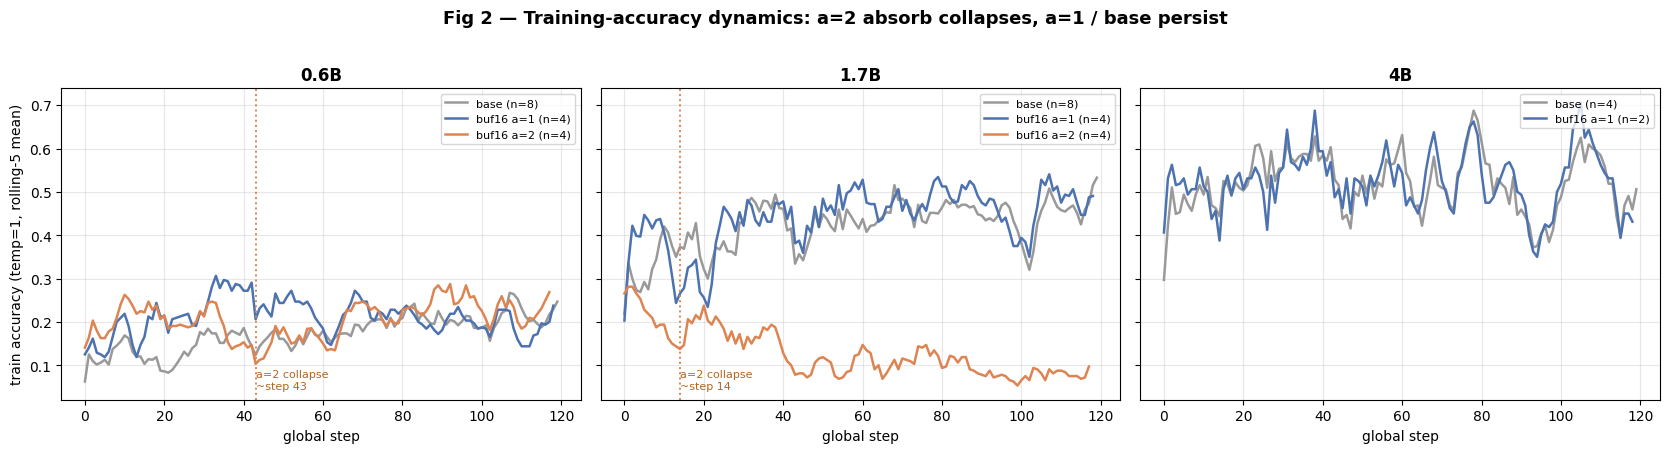

In [7]:
# ===========================================================================
# FIGURE 2 — Collapse dynamics. eval_rollout only logs init+final, so we use
# TRAIN rollouts (rollouts.jsonl: per global_step, temp=1 sampled pass-rate) to
# trace accuracy over training. Compares base vs buf16_a1 vs buf16_a2 per size;
# a=2 (aggressive absorb) is expected to collapse, especially at 1.7B.
# ===========================================================================
import matplotlib.pyplot as plt

KEEP_F2 = {"base", "lottery_buf16_a1", "lottery_buf16_a2"}

def load_train_acc(keep_methods) -> pd.DataFrame:
    rows = []
    for src in SOURCES:
        root = Path(src)
        is_lot = "lottery" in root.name.lower()
        for f in root.glob("**/rollouts.jsonl"):
            run = f.relative_to(root).parts[0]
            method, size = parse_run(run, str(f), is_lot)
            if method not in keep_methods or size not in SIZE_ORDER:
                continue
            for line in f.open():
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                rows.append({"method": method, "size": size,
                             "run": f"{root.name}/{run}",
                             "step": int(r["global_step"]), "correct": bool(r["correct"])})
    return pd.DataFrame(rows)

train = load_train_acc(KEEP_F2)
# per-run per-step accuracy -> mean over runs per (method,size,step)
per_run_step = train.groupby(["method", "size", "run", "step"]).correct.mean().reset_index()
curve = (per_run_step.groupby(["method", "size", "step"]).correct
                     .agg(["mean", "std", "count"]).reset_index())  # count = #seeds at that step

W = 5  # rolling window (steps) to denoise the temp=1 train pass-rate
sizes_f2 = [s for s in SIZE_ORDER if s in curve["size"].unique()]
style = {"base": ("#999999", "base"),
         "lottery_buf16_a1": ("#4C72B0", "buf16 a=1"),
         "lottery_buf16_a2": ("#DD8452", "buf16 a=2")}

fig, axes = plt.subplots(1, len(sizes_f2), figsize=(5.6 * len(sizes_f2), 4.4),
                         squeeze=False, sharey=True)
for ci, size in enumerate(sizes_f2):
    ax = axes[0][ci]
    for method, (color, lbl) in style.items():
        d = curve[(curve["size"] == size) & (curve.method == method)].sort_values("step")
        if d.empty:
            continue
        n_seeds = int(d["count"].max())
        roll = d["mean"].rolling(W, min_periods=1).mean().values
        ax.plot(d["step"].values, roll, color=color, lw=1.8, label=f"{lbl} (n={n_seeds})")
        # collapse marker for a=2: first post-peak step where rolling acc < 50% of peak
        if method == "lottery_buf16_a2" and len(roll) > W:
            peak = np.nanmax(roll[:max(1, len(roll)//3)])  # early-training peak
            below = np.where(roll < 0.5 * peak)[0]
            if below.size:
                cs = int(d["step"].values[below[0]])
                ax.axvline(cs, ls=":", color="#DD8452", lw=1.4)
                ax.text(cs, 0.04, f"a=2 collapse\n~step {cs}", color="#B5651D",
                        fontsize=8, ha="left", va="bottom")
    ax.set_title(size, fontsize=12, fontweight="bold")
    ax.set_xlabel("global step"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")
    if ci == 0:
        ax.set_ylabel(f"train accuracy (temp=1, rolling-{W} mean)")
fig.suptitle("Fig 2 — Training-accuracy dynamics: a=2 absorb collapses, a=1 / base persist",
             y=1.02, fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


winners per size (by final avg greedy@1, n_runs>=2):
  0.6B: ['insert_max', 'insert_min']
  1.7B: ['lottery_buf16_a1', 'buf_base']
  4B: ['insert_min', 'insert_max_min']
reduced method set: ['base', 'buf_base', 'insert_max', 'insert_max_min', 'insert_min', 'lottery_buf16_a1']


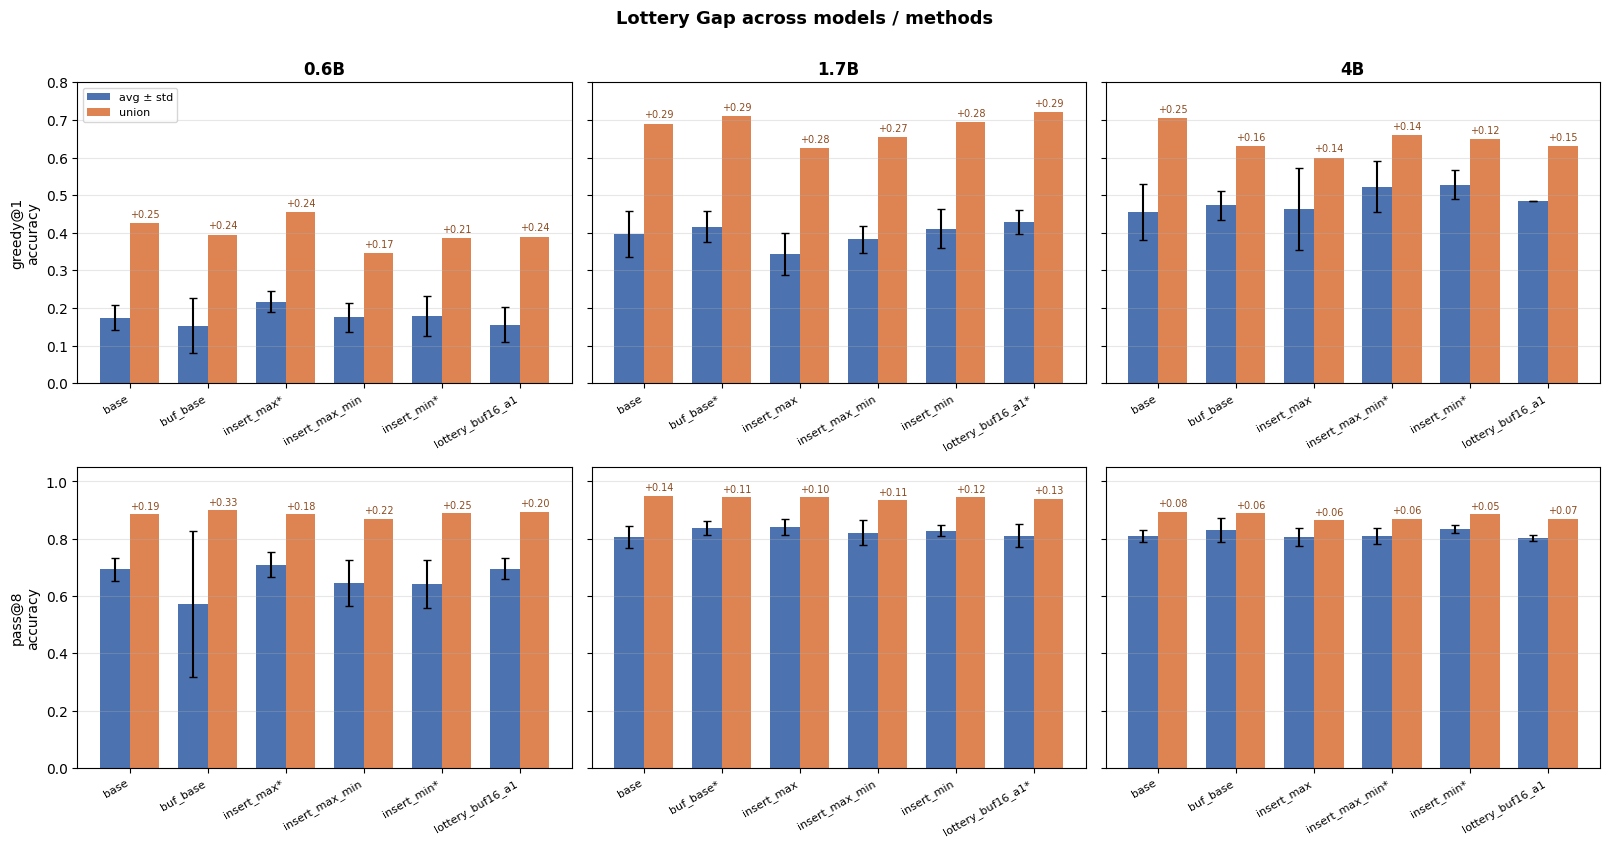

In [8]:
# ===========================================================================
# FIGURE 3 — Winners only, FINAL checkpoint. For each size, rank non-base
# methods by final avg greedy@1 (require >=2 seeds to avoid single-run noise),
# take the top-N as that size's "winners". Reduce the figure to base + the
# union of per-size winners. Shows avg (±std) vs union, greedy@1 and pass@K.
# ===========================================================================
import matplotlib.pyplot as plt

TOPN = 2
final = summary[summary.stage == "final"]
sizes_f3 = [s for s in SIZE_ORDER if s in final["size"].unique()]

winners_by_size = {}
for size in sizes_f3:
    sub = final[(final["size"] == size) & (final.method != "base") & (final.n_runs >= 2)]
    sub = sub.dropna(subset=["avg_greedy@1_mean"]).sort_values("avg_greedy@1_mean", ascending=False)
    winners_by_size[size] = sub.head(TOPN).method.tolist()
print("winners per size (by final avg greedy@1, n_runs>=2):")
for s, w in winners_by_size.items():
    print(f"  {s}: {w}")# C# # Msdssdsdsdaassdssdffssadadsssssdssdssdsdssssdsdssdsdsssssdsdsdasdasdwwaweqqqqqwweq# M

keep = ["base"] + sorted({m for ws in winners_by_size.values() for m in ws})
print("reduced method set:", keep)

metric_specs = [("greedy@1", "union_greedy@1", "avg_greedy@1_mean", "avg_greedy@1_std"),
                (f"pass@{K}", f"union_pass@{K}", f"avg_pass@{K}_mean", f"avg_pass@{K}_std")]

fig, axes = plt.subplots(len(metric_specs), len(sizes_f3),
                         figsize=(max(4.5, 0.9 * len(keep)) * len(sizes_f3),
                                  4.2 * len(metric_specs)),
                         squeeze=False, sharey="row")
for ri, (label, ucol, mcol, scol) in enumerate(metric_specs):
    for ci, size in enumerate(sizes_f3):
        ax = axes[ri][ci]
        sub = (final[final["size"] == size].set_index("method").reindex(keep))
        x = np.arange(len(keep)); w = 0.38
        means, stds, unions = sub[mcol].values, np.nan_to_num(sub[scol].values), sub[ucol].values
        # highlight winners for this size with a star on the xtick label
        labels = [m + ("*" if m in winners_by_size.get(size, []) else "") for m in keep]
        ax.bar(x - w/2, means, w, yerr=stds, capsize=3, color="#4C72B0", label="avg ± std")
        ax.bar(x + w/2, unions, w, color="#DD8452", label="union")
        for xi, (mn, u) in enumerate(zip(means, unions)):
            if np.isfinite(mn) and np.isfinite(u):
                ax.text(xi + w/2, u + 0.01, f"+{u-mn:.2f}", ha="center", va="bottom",
                        fontsize=7, color="#8C4A1F")
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.set_ylim(0, 0.8 if ri == 0 else 1.05); ax.grid(axis="y", alpha=0.3)
        if ri == 0:
            ax.set_title(size, fontsize=12, fontweight="bold")
        if ci == 0:
            ax.set_ylabel(f"{label}\naccuracy")
        if ri == 0 and ci == 0:
            ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Lottery Gap across models / methods", y=1.003, fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


In [ ]:
# [Question]. What if we re-use the data order from the 'best seed'? 
#             or rather, the questions is whether acc of 'best seed' diverge from other seeds early on? 

# [Question]. On RandOpt, why don't we apply it on step 1, instead of step 12? 

# Best of N with verifier of course retrieve the performance perfectly, best-of-N consistency also helps on GSM8K

# [Wild Idea]. Adding experts to MLP (direct copy weight of MLP), un-freeze one experts (and fixed routing) for every seed run
#              after N seed runs, we have N different experts, then, we'd conduct a "calibration" phase where we specifically 
#              train the MoE router to be able to select the "best expert" given any query

# 

In [ ]:
# M3PO


Basic Idea of M2PO: 
$$
\hat{M}_{2, i} = \log [\frac{\pi_{\theta}(a_{i} | s_{i})}{\pi_{behav}(a_{i} | s_{i})}]^2
$$
we "mask out" rollouts with $\arg\max_{i} \hat{M}_{2, i}$ until $\frac{1}{N} \sum_{i=1}^{N}\hat{M}_{2, i} \leq \pi_{M_2}$, masking out means we clip rollout's gradient to 0. 

To implement this logic, we need to modify the buffer (PrefixTrie I believe) to also record $\log \pi(a | s)$ (log likelihood of current sequence under current model), this allows us to use 
- (1). normal GRPO gradient clipping
- (2). M2PO rollout masking

In [ ]:
# whether 8x seed union accuracy outperforms 8x batch size? 
# Qwen3-0.6B, Game of 24, 8 seeds, B=2
# avg. acc : 17.3%
# union acc: 51.4%
# lottery gap: 34.1%
# intersection: 0.4%
# soup uniform merge: 20.9%
# soup merge at step 1 -> train: 21.3%

# Qwen3-0.6B, Game of 24, B=16, 2 seeds
# avg. acc: 18.4% | acc doesn't move with bigger batch size

# Qwen3-0.6B, GSM8K, 8 seeds
# avg. acc: 70.7%
# union. acc: 92.4%
# lottery gap: 21.7%
# intersection: 36.7%
# soup uniform merge: 76.6%
# soup merge at step 1 -> train: 73.2%

# Qwen3-0.6B, GSM8K B=16, 2 seeds
# avg. acc: 71.8% | acc doesn't move with bigger batch size

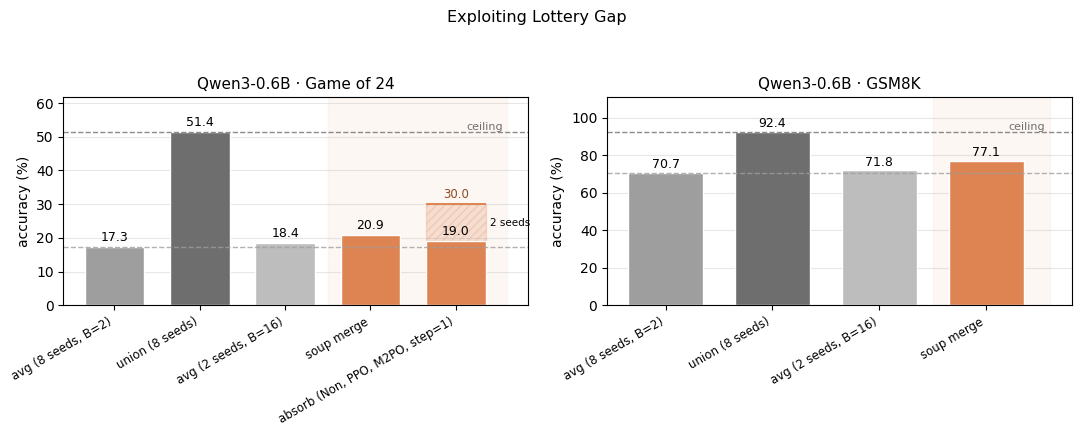

In [13]:
import numpy as np, matplotlib.pyplot as plt

# Data: does 8x-seed union beat 8x batch size? (Qwen3-0.6B)
#   references (muted):  avg (8 seeds, B=2) | union ceiling | avg (2 seeds, B=16)
#   exploits   (accent): attempts to cash in the lottery gap -> soup merge, absorb
DATA = {
    "Game of 24": dict(avg=17.3, union=51.4, bigbatch=18.4, soup=20.9, absorb=19.0, inter=0.4),
    "GSM8K":      dict(avg=70.7, union=92.4, bigbatch=71.8, soup=77.1, inter=36.7),
}
# (label, key, color) — references kept grey so the eye lands on the exploits
REF = [("avg (8 seeds, B=2)", "avg",      "#9E9E9E"),
       ("union (8 seeds)",     "union",    "#6E6E6E"),
       ("avg (2 seeds, B=16)", "bigbatch", "#BDBDBD")]
EXPLOIT_COLOR = "#DD8452"
EXPLOITS = [("soup merge", "soup", EXPLOIT_COLOR)]
EXPLOIT_EXTRA = {
    "Game of 24": [("absorb (Non, PPO, M2PO, step=1)", "absorb", EXPLOIT_COLOR)],
}
# bars whose true value is a measured *range* (running avg over 2 seeds / configs)
RANGES = {"absorb": (19.0, 30.0)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=False)
for ax, (task, d) in zip(axes, DATA.items()):
    bars_def = REF + EXPLOITS + EXPLOIT_EXTRA.get(task, [])
    n_ref = len(REF)
    x = np.arange(len(bars_def))
    vals = [d[k] for _, k, _ in bars_def]
    cols = [c for _, _, c in bars_def]

    # shade the "exploit" zone so the right-hand bars read as one group
    ax.axvspan(n_ref - 0.5, len(bars_def) - 0.4, color=EXPLOIT_COLOR, alpha=0.06, zorder=0)

    bars = ax.bar(x, vals, color=cols, width=0.7, edgecolor="white", zorder=2)
    for b, (_, k, c), v in zip(bars, bars_def, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
        # measured-range artifact: shaded band from lo->hi on top of the bar
        if k in RANGES:
            lo, hi = RANGES[k]
            ax.bar(b.get_x() + b.get_width()/2, hi - lo, bottom=lo, width=b.get_width(),
                   facecolor=c, alpha=0.22, hatch="////", edgecolor=c, lw=1.0, zorder=1)
            ax.hlines(hi, b.get_x(), b.get_x() + b.get_width(), color=c, lw=1.4, zorder=3)
            ax.text(b.get_x() + b.get_width()/2, hi + 1, f"{hi:.1f}", ha="center",
                    va="bottom", fontsize=8.5, color="#8C4A1F")
            ax.text(b.get_x() + b.get_width() + 0.05, (lo + hi)/2,
                    "2 seeds", fontsize=7.5, va="center")

    # reference floor (avg) and ceiling (union) lines for the exploits to beat
    ax.axhline(d["avg"],   ls="--", lw=1, color="#9E9E9E", alpha=0.8)
    ax.axhline(d["union"], ls="--", lw=1, color="#6E6E6E", alpha=0.8)
    ax.text(len(bars_def) - 0.45, d["union"], "ceiling", fontsize=8, va="bottom",
            ha="right", color="#6E6E6E")

    ax.set_xticks(x)
    ax.set_xticklabels([n for n, _, _ in bars_def], rotation=30, ha="right", fontsize=8.5)
    ax.set_ylim(0, max(vals + [RANGES.get(k, (0, 0))[1] for _, k, _ in bars_def]) * 1.2)
    ax.set_title(f"Qwen3-0.6B · {task}", fontsize=11)
    ax.set_ylabel("accuracy (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Exploiting Lottery Gap", fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Takeaway: union over 8 seeds >> avg, and >> big-batch (B=16) avg, which is ~flat vs B=2.
# i.e. the gains live in *seed diversity* (lottery), not in larger batch size.
# The right-hand (orange) bars are exploits that try to cash that gap into a single model.


In [ ]:
# Game of 24
# PPO clipped absorb runs (absorb step=1): 19.0
# 
# GSM8K
# soup merge:  0.771